# TP Diffusion - Sommerfeld - Analyse des images

## Partie 1 - Extraction de $h$ en fonction du temps

# TP Diffusion - Sommerfeld - Analyse des images

## Partie 1 - Extraction de $h$ en fonction du temps

L’objectif de cette partie est de déterminer la déflexion verticale maximale $h$ du faisceau laser en fonction du temps à partir des images expérimentales. Cette grandeur permet ensuite d’étudier l’évolution temporelle de l’angle de déviation maximal $\alpha_{\max}$ du faisceau. Cet angle n’est pas mesuré directement : il est déduit de la valeur de $h$, correspondant à la distance verticale entre la trajectoire déviée du faisceau et sa trajectoire rectiligne de référence.

Dans cette première partie, après un prétraitement des images sous Fiji (seuillage et squelettisation), les coordonnées des pixels constituant la feuille laser sont exportées. Le traitement est ensuite réalisé sous Python : à partir des coordonnées $(x,y)$, la trajectoire du faisceau est reconstruite pour chaque image, une droite de référence est déterminée, puis la déflexion verticale maximale est calculée. 
 

On renseigne le nom du dossier ainsi que le facteur de conversion pixel/m (imageJ).


In [26]:
import numpy as np

csv_path = "skeleton_pixels.csv"   # adapte le nom si besoin
csv_data = np.loadtxt(csv_path, delimiter=",", skiprows=1)

# ex:(3331.66 px = 15 cm, PX_TO_M = 0.15 / 3331.66)
PX_TO_M = 0.15 / 3331.66


### 1. Extraction de la trajectoire du faisceau et calcul de la déviation

À partir du fichier \texttt{CSV} contenant les coordonnées $(x,y)$ des pixels du squelette pour chaque image, un traitement est effectué sous Python afin de reconstruire la trajectoire de la feuille laser et d’en extraire la déflexion verticale maximale. Pour chaque image, la position verticale du faisceau est estimée colonne par colonne comme la médiane des coordonnées $y$ associées à une même abscisse $x$, ce qui permet d’obtenir une courbe robuste vis-à-vis des petites irrégularités du squelette. La courbe est ensuite interpolée et lissée à l’aide d’un filtre gaussien afin d’obtenir une trajectoire continue. Une droite de référence, correspondant à la trajectoire rectiligne du faisceau à l’équilibre diffusif, est déterminée à partir de la première image et conservée pour l’ensemble de la séquence. La déflexion verticale est alors définie comme la différence entre la trajectoire reconstruite et la droite de référence. La hauteur maximale $h$ est identifiée comme la valeur maximale positive de cette déflexion dans une région d’intérêt.


In [27]:
import numpy as np
from scipy.ndimage import gaussian_filter1d



# Reconstruit la courbe y(x) à partir des points (x,y) en prenant, pour chaque x, la médiane des y associés

def curve_from_xy(xs, ys, W):
    # Tableau contenant y(x) pour x = 0 ... W-1
    y = np.full(W, np.nan)

    # Pour chaque colonne x présente dans les données
    for x in np.unique(xs):
        # On prend la médiane des valeurs y correspondantes
        y[x] = np.median(ys[xs == x])

    return y



# Calcule la déflexion verticale maximale h pour chaque image à partir d'un fichier CSV contenant slice, x, y

def dmax_from_csv(csv_data, ref=None,
                  roi_left=0.1, roi_right=0.9,
                  edge_margin=0.05, smooth_sigma=10.0):

    # Séparation des colonnes du CSV
    slices = csv_data[:, 0].astype(int)   # numéro d'image
    xs_all = csv_data[:, 1].astype(int)   # coordonnées x
    ys_all = csv_data[:, 2].astype(float) # coordonnées y

    results = []   # contiendra (slice, dmax)

    # Boucle sur toutes les images du stack
    for s in np.unique(slices):

        # Sélection des points correspondant à l'image s
        sel = slices == s
        xs = xs_all[sel]
        ys = ys_all[sel]

        # Largeur de l'image (en pixels)
        W = xs.max() + 1

        # Reconstruction de la courbe brute y(x)
        y_raw = curve_from_xy(xs, ys, W)

        # Colonnes pour lesquelles on a une valeur valide
        valid = np.isfinite(y_raw)
        x_valid = np.where(valid)[0]

        # Si trop peu de points valides, on renvoie h = 0
        if x_valid.size < 5:
            results.append((s, 0.0))
            continue

        # Interpolation pour obtenir une courbe continue
        y_interp = np.interp(np.arange(W),
                              x_valid,
                              y_raw[valid])

        # Lissage par filtre gaussien
        y_smooth = gaussian_filter1d(y_interp,
                                     sigma=smooth_sigma)

        # Construction de la droite de référence (uniquement sur la première image)
        if ref is None:

            # On ignore les bords de l'image
            m = int(edge_margin * W)
            good = np.isfinite(y_smooth)
            good[:m] = False
            good[W - m:] = False

            xs_ref = np.where(good)[0]

            x1, x2 = xs_ref[0], xs_ref[-1]
            y1, y2 = y_smooth[x1], y_smooth[x2]

            # Stockage de la référence
            ref = (x1, y1, x2, y2)

        else:
            x1, y1, x2, y2 = ref

        # Équation de la droite de référence
        slope = (y2 - y1) / (x2 - x1)
        xgrid = np.arange(W)
        y_line = y1 + slope * (xgrid - x1)

        # Calcul de la déflexion verticale
        d = y_smooth - y_line

        # Définition de la région d'intérêt
        xmin = int(roi_left * W)
        xmax = int(roi_right * W)

        good = np.isfinite(d) & (d > 0)
        good[:xmin] = False
        good[xmax:] = False

        # Hauteur maximale
        dmax = float(np.max(d[good])) if np.any(good) else 0.0

        results.append((s, dmax))

    return np.array(results), ref



### 5. Traitement de l’ensemble de la séquence d’images

On applique maintenant la fonction précédente à toutes les images du dossier.
Pour chaque image, la déviation verticale maximale est calculée en pixels,
puis convertie en mètres.


In [28]:
results, ref = dmax_from_csv(csv_data)

PX_TO_M = 0.15 / 3331.66   # m / pixel

# Conversion pixels -> mètres
h = results.copy()
h[:,1] *= PX_TO_M
h = h[:, 1]

print("h (m)")
print(h)



h (m)
[0.03362712 0.0289725  0.02590277 0.02375002 0.02167061 0.02065062
 0.01907387 0.01813387 0.01740366 0.01672681 0.01594266 0.01551507
 0.01488414 0.01423902 0.01405938 0.01361022 0.01333295 0.01288098
 0.01261227 0.01219133 0.01191853 0.01168561 0.01160764 0.01144467
 0.01115715 0.0109435  0.01085528 0.0106354  0.01045537]


### 5. Visualisation

La fonction show permet de visualiser, pour une image donnée, le résultat final de la détection
du creux de la feuille laser.

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d


import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

def compute_curve_and_d(csv_data, slice_id, ref,
                        roi_left=0.1, roi_right=0.9,
                        smooth_sigma=10.0):

    slices = csv_data[:,0].astype(int)
    xs_all = csv_data[:,1].astype(int)
    ys_all = csv_data[:,2].astype(float)

    sel = slices == slice_id
    xs = xs_all[sel]
    ys = ys_all[sel]

    W = xs.max() + 1
    xgrid = np.arange(W)

    # reconstruction courbe
    y_raw = curve_from_xy(xs, ys, W)

    valid = np.isfinite(y_raw)
    x_valid = np.where(valid)[0]

    y_interp = np.interp(xgrid, x_valid, y_raw[valid])
    y_smooth = gaussian_filter1d(y_interp, sigma=smooth_sigma)

    # ligne de référence
    x1, y1, x2, y2 = ref
    slope = (y2 - y1)/(x2 - x1)
    y_line = y1 + slope*(xgrid - x1)

    # déflexion
    d = y_smooth - y_line

    xmin = int(roi_left * W)
    xmax = int(roi_right * W)

    good = np.isfinite(d) & (d > 0)
    good[:xmin] = False
    good[xmax:] = False

    if not np.any(good):
        return xgrid, y_smooth, y_line, d, None, 0.0

    idx = np.argmax(np.where(good, d, -np.inf))
    dmax = float(d[idx])

    return xgrid, y_smooth, y_line, d, idx, dmax

def plot_slice(csv_data, slice_id, ref,
                     roi_left=0.1, roi_right=0.9,
                     smooth_sigma=10.0,
                     px_to_m=None):
    xgrid, y_smooth, y_line, d, idx, dmax = compute_curve_and_d(
        csv_data, slice_id, ref,
        roi_left=roi_left, roi_right=roi_right,
        smooth_sigma=smooth_sigma
    )

    # conversions optionnelles (pour afficher h en mètres)
    dmax_disp = dmax
    unit = "px"
    if px_to_m is not None:
        dmax_disp = dmax * px_to_m
        unit = "m"

    plt.figure()
    plt.plot(xgrid, y_smooth, label="Courbe (médiane + lissage)")
    plt.plot(xgrid, y_line, label="Ligne de référence")

    if idx is not None:
        # segment vertical montrant h
        plt.plot([idx, idx], [y_line[idx], y_smooth[idx]], linewidth=2)
        plt.scatter([idx], [y_smooth[idx]])
        plt.scatter([idx], [y_line[idx]])
        plt.title(f"Slice {slice_id} — h = {dmax_disp:.4g} {unit} (idx={idx})")
    else:
        plt.title(f"Slice {slice_id} — aucune déflexion positive dans la ROI")

    plt.xlabel("x (pixels)")
    plt.ylabel("y (pixels)")
    plt.legend()
    plt.gca().invert_yaxis()  # optionnel: comme une image (y vers le bas)
    plt.show()


En faisant varier l’indice i, il est possible d’accéder à chaque image individuellement et d’identifier la position du creux détecté par l’algorithme. 

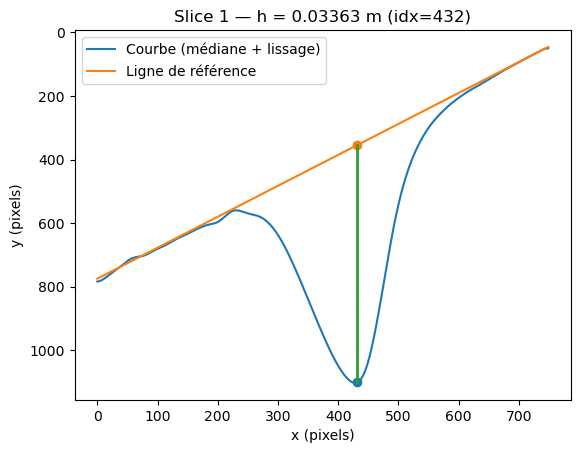

In [30]:
plot_slice(csv_data, slice_id=1, ref=ref,
                 roi_left=0.1, roi_right=0.9,
                 smooth_sigma=10.0,
                 px_to_m=PX_TO_M)

# Partie 2 – Détermination du coefficient de diffusion $D$

À l’issue de la partie 1, on obtient une liste nommée h, contenant les valeurs de déflexion verticales maximales $h$ en fonction du temps.

On cherche à déterminer le coefficient de diffusion $D$ à partir de l’évolution temporelle de l’angle de déviation maximal du faisceau laser, noté $\alpha_{\text{max}}$.

D’après le modèle théorique, cet angle vérifie :

$$
\alpha_{\text{max}}
= d\,\frac{n_g - n_w}{c_g}\,\frac{c_0}{2\sqrt{\pi D t}}
$$

Cette expression montre que, pour des temps suffisamment longs, $\alpha_{\text{max}}$ est proportionnel à $t^{-1/2}$.

---

## Travail demandé

1. À partir des profondeurs maximales $h(t)$ obtenues à la Partie 1, calculer l’angle de déviation maximal à chaque instant t:

$$
\alpha_{\text{max}} = \arctan\left(\frac{h}{X}\right)
$$

où $X$ est la distance entre la sortie de la cuve et l’écran.

2. Tracer $\alpha_{\text{max}}$ en fonction de $t^{-1/2}$.

3. Sélectionner le domaine de temps longs (par exemple $t \geq 1$ h), pour lequel le régime asymptotique est atteint.

4. Sur ces points, effectuer un ajustement linéaire (passant par l’origine) et en extraire la pente.

5. En déduire le coefficient de diffusion $D$ à partir de la pente.

6. Propager les incertitudes :
   - les incertitudes sur $h$ et sur $X$ afin d’estimer l’incertitude sur $\alpha_{\text{max}}$,
   - l’incertitude sur la pente issue de l’ajustement,
   - puis l’incertitude finale sur $D$.

---





In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Données
h=h
incertitude_h=0.01

# distance entrée de la cuve-écran en m
X = 17.6e-2  
incertitude_X = 1e-3 

# largeur de la cuve en m
d = 2.03e-2     
incertitude_d = 0.01e-2

# indices optique du glycérol pur et de l'eau
n_g = 1.473
n_w = 1.333

# concentration molaire du glycérol pur et du glycérol 25%
c_g = 13.7e3         # mol/m³
c_0 = c_g / 4
incertitude_c_0 = 6e2  # incertitude sur c_0 (~10%)

# Temps
t_min = np.arange(5, 5*(len(h)+1), 5) 
t_s = t_min * 60          # secondes
t_h = t_s / 3600          # heures pour axe du haut

L'angle de déviation est calculé par :

$$
\alpha = \arctan\left(\frac{h}{X}\right)
$$

On définit ensuite la variable :

$$
x = t^{-1/2}
$$


In [32]:
alpha = np.arctan(h / X)

x = 1 / np.sqrt(t_s)

Pour les temps longs (ici $t \geq 1$ heure), la théorie prédit :

$$
\alpha = \text{pente} \cdot t^{-1/2}
$$

On effectue donc un ajustement linéaire.


In [38]:
mask = t_h >= 1
x_fit_data = x[mask]
alpha_fit_data = alpha[mask]

slope = np.dot(x_fit_data, alpha_fit_data) / np.dot(x_fit_data, x_fit_data)
print(f"Slope (t ≥ 1 h) = {slope:.4e} rad·s^(1/2)")


Slope (t ≥ 1 h) = 5.3825e+00 rad·s^(1/2)


On trace :
- les données expérimentales $\alpha(t^{-1/2})$
- la droite d'ajustement
- un axe supérieur indiquant le temps en heures

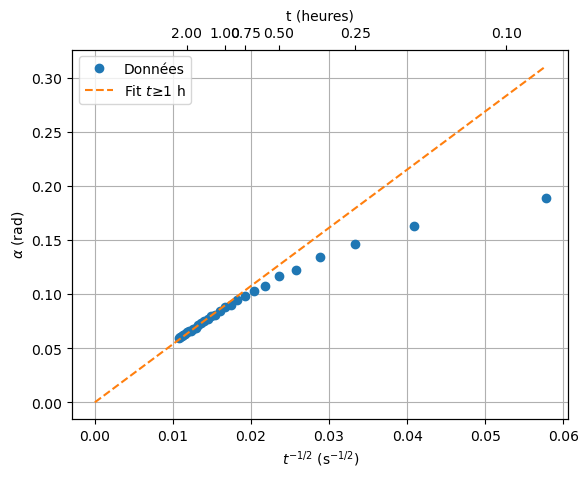

slope = 5.3825e+00 rad·s^(1/2)


In [39]:
x_fit = np.linspace(0, x.max(), 200)
alpha_fit = slope * x_fit

fig, ax = plt.subplots()
ax.plot(x, alpha, 'o', label='Données')
ax.plot(x_fit, alpha_fit, '--', label=f'Fit $t ≥ 1$ h')
ax.set_xlabel(r'$t^{-1/2}$ (s$^{-1/2}$)')
ax.set_ylabel(r'$\alpha$ (rad)')
ax.grid(True)
ax.legend()

# Axe du haut : temps en heures
ax_top = ax.twiny()
t_ticks_h = np.array([0.1, 0.25, 0.5, 0.75, 1, 2])
x_ticks = 1 / np.sqrt(t_ticks_h * 3600)
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(x_ticks)
ax_top.set_xticklabels([f"{t:.2f}" for t in t_ticks_h])
ax_top.set_xlabel("t (heures)")

plt.show()
print(f"slope = {slope:.4e} rad·s^(1/2)")

On propage les incertitudes :

- sur $\alpha$ via l'incertitude sur $X$
- sur la pente via une moyenne des incertitudes sur $\alpha$


In [40]:
# Propagation d'incertitude sur alpha due à X
delta_alpha = alpha * np.sqrt((incertitude_h / h)**2 + (incertitude_X / X)**2)

# Pour la slope, approximation : Δslope ~ moyenne pondérée de Δα
delta_slope = np.mean(delta_alpha[mask])



On calcule ensuite la constante intermédiaire :

$
C = \frac{d c_0 (n_g - n_w)}{2 c_g \sqrt{\pi}}
$

Puis le coefficient de diffusion :

$
D = \left(\frac{C}{\text{slope}}\right)^2
$


In [41]:
C = (d * c_0 * (n_g - n_w)) / (2 * c_g * np.sqrt(np.pi))

D = (C / slope)**2

# Propagation d'incertitude sur C et D
rel_d = incertitude_d / d
rel_c0 = incertitude_c_0 / c_0
delta_C = C * np.sqrt(rel_d**2 + rel_c0**2)

delta_D = D * 2 * np.sqrt( (delta_C / C)**2 + (delta_slope / slope)**2 )

print(f"C = {C:.4e} ± {delta_C:.4e} m³/mol")
print(f"D = {D:.4e} ± {delta_D:.4e} m²/s")

C = 2.0043e-04 ± 3.5125e-05 m³/mol
D = 1.3866e-09 ± 4.8689e-10 m²/s


### Comparaison avec D=kT/6pietaR



In [37]:
import numpy as np

# Constantes
kB = 1.380649e-23        # J/K
T = 291.15               # K (18 °C)
eta = 0.001           
R = 1.0e-10              

# Coefficient de diffusion (Stokes–Einstein)
D = kB * T / (6 * np.pi * eta * R)

print(f"D = {D:.3e} m^2/s")


D = 2.133e-09 m^2/s
